# League of Legends Win Prediction - 2025 Edition

**Predicting player performance and match outcomes using AutoML**

This notebook demonstrates how to build ML models that predict:
1. **Player Performance Score** - A calculated metric based on in-game statistics
2. **Win/Loss Outcome** - Binary classification of match results
3. **Live Client Compatible Model** - Lightweight model for real-time predictions

---

## Architecture Overview

```
+-------------------+     +------------------+     +------------------+
|   Riot Games API  | --> |  Data Pipeline   | --> |  Training Data   |
+-------------------+     +------------------+     +------------------+
                                                           |
                                                           v
+-------------------+     +------------------+     +------------------+
|   Live Client     | --> | Trained Models   | <-- |    AutoGluon     |
+-------------------+     +------------------+     +------------------+
        |                         |
        v                         v
+-------------------+     +------------------+
| Real-time Stats   | --> |   Predictions    |
+-------------------+     +------------------+
```

## 1. Environment Setup

In [1]:
# Install dependencies if needed (uncomment to run)
!pip install autogluon pandas numpy matplotlib seaborn scikit-learn plotly

In [2]:
# Core imports
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularDataset, TabularPredictor

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)

# Paths - relative to notebook location
DATA_DIR = Path('./data')
MODELS_DIR = Path('./models')
MODELS_DIR.mkdir(exist_ok=True)

print(f"Data directory: {DATA_DIR.absolute()}")
print(f"Models directory: {MODELS_DIR.absolute()}")

Data directory: /home/ubuntu/git/leagueoflegends-optimizer/notebooks/data
Models directory: /home/ubuntu/git/leagueoflegends-optimizer/notebooks/models


## 2. Data Loading & Exploration

In [3]:
# Load the performance dataset
df = pd.read_csv(
    DATA_DIR / 'performance_report.csv',
    index_col=0,
    low_memory=False
)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Dataset shape: 3,827,782 rows x 112 columns


Memory usage: 5.36 GB


In [4]:
# Quick data overview
df.head(3)

,assists,baronKills,bountyLevel,champExperience,champLevel,championId,championName,championTransform,consumablesPurchased,damageDealtToBuildings,damageDealtToObjectives,damageDealtToTurrets,damageSelfMitigated,deaths,detectorWardsPlaced,doubleKills,dragonKills,firstBloodAssist,firstBloodKill,firstTowerAssist,firstTowerKill,gameEndedInEarlySurrender,gameEndedInSurrender,goldEarned,goldSpent,...,totalMinionsKilled,totalTimeCCDealt,totalTimeSpentDead,totalUnitsHealed,tripleKills,trueDamageDealt,trueDamageDealtToChampions,trueDamageTaken,turretKills,turretTakedowns,turretsLost,unrealKills,visionScore,visionWardsBoughtInGame,wardsKilled,wardsPlaced,win,match_identifier,duration,f1,f2,f3,f4,f5,calculated_player_performance
0,9.0,0.0,0.0,24496.0,18.0,39.0,Irelia,0.0,1.0,5039.0,11870.0,5039.0,61858.0,11.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20032.0,17500.0,...,287.0,203.0,398.0,1.0,1.0,3343.0,957.0,4779.0,2.0,2.0,3.0,0.0,13.0,0.0,2.0,5.0,1.0,2.317437e+09,37.686583,0.291881,0.636831,0.477624,7578.877540,531.541950,48.55
1,4.0,0.0,0.0,19450.0,18.0,105.0,Fizz,0.0,5.0,4882.0,8988.0,4882.0,12302.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15431.0,15425.0,...,266.0,261.0,166.0,1.0,0.0,11103.0,948.0,546.0,3.0,5.0,3.0,0.0,23.0,3.0,3.0,6.0,1.0,2.317437e+09,37.686583,0.079604,0.238812,0.477624,4770.849042,409.456062,56.34
2,7.0,1.0,5.0,21297.0,18.0,24.0,Jax,0.0,6.0,3817.0,38541.0,3817.0,32389.0,3.0,4.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,16432.0,12750.0,...,67.0,325.0,120.0,1.0,2.0,12395.0,1143.0,446.0,2.0,4.0,3.0,0.0,54.0,6.0,10.0,15.0,1.0,2.317437e+09,37.686583,0.079604,0.477624,0.477624,6320.976298,436.017239,69.25


In [5]:
# Column types summary
print("\nColumn Types:")
print(df.dtypes.value_counts())

print("\nKey columns:")
key_cols = ['kills', 'deaths', 'assists', 'win', 'championName', 'calculated_player_performance']
df[key_cols].describe()


Column Types:
float64    104
object       8
Name: count, dtype: int64

Key columns:


,kills,deaths,assists,win,calculated_player_performance
count,3.827782e+06,3.827782e+06,3.827782e+06,3.827782e+06,3.827782e+06
mean,5.556692e+00,5.550949e+00,7.871683e+00,4.995749e-01,4.918131e+01
std,4.515094e+00,3.135687e+00,5.772486e+00,4.999999e-01,2.228066e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.356100e+02
25%,2.000000e+00,3.000000e+00,4.000000e+00,0.000000e+00,3.362000e+01
50%,5.000000e+00,5.000000e+00,7.000000e+00,0.000000e+00,4.882000e+01
75%,8.000000e+00,8.000000e+00,1.100000e+01,1.000000e+00,6.495000e+01
max,4.800000e+01,3.400000e+01,5.500000e+01,1.000000e+00,2.279500e+02


### 2.1 Target Variable Analysis

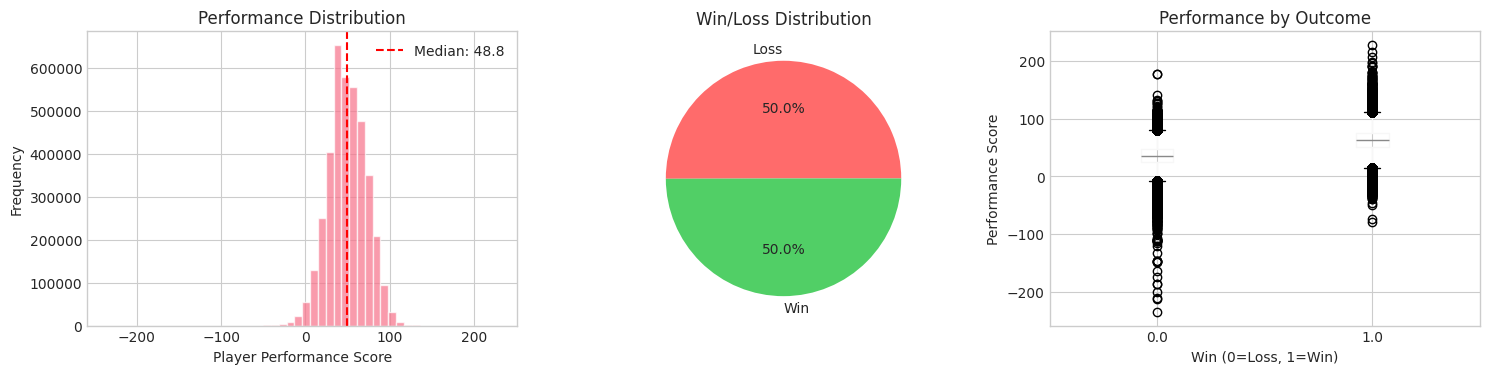

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Performance distribution
axes[0].hist(df['calculated_player_performance'], bins=50, edgecolor='white', alpha=0.7)
axes[0].axvline(df['calculated_player_performance'].median(), color='red', linestyle='--', label=f"Median: {df['calculated_player_performance'].median():.1f}")
axes[0].set_xlabel('Player Performance Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Performance Distribution')
axes[0].legend()

# Win rate
win_counts = df['win'].value_counts()
axes[1].pie(win_counts, labels=['Loss', 'Win'], autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'])
axes[1].set_title('Win/Loss Distribution')

# Performance by win/loss
df.boxplot(column='calculated_player_performance', by='win', ax=axes[2])
axes[2].set_xlabel('Win (0=Loss, 1=Win)')
axes[2].set_ylabel('Performance Score')
axes[2].set_title('Performance by Outcome')
plt.suptitle('')

plt.tight_layout()
plt.show()

### 2.2 Feature Analysis

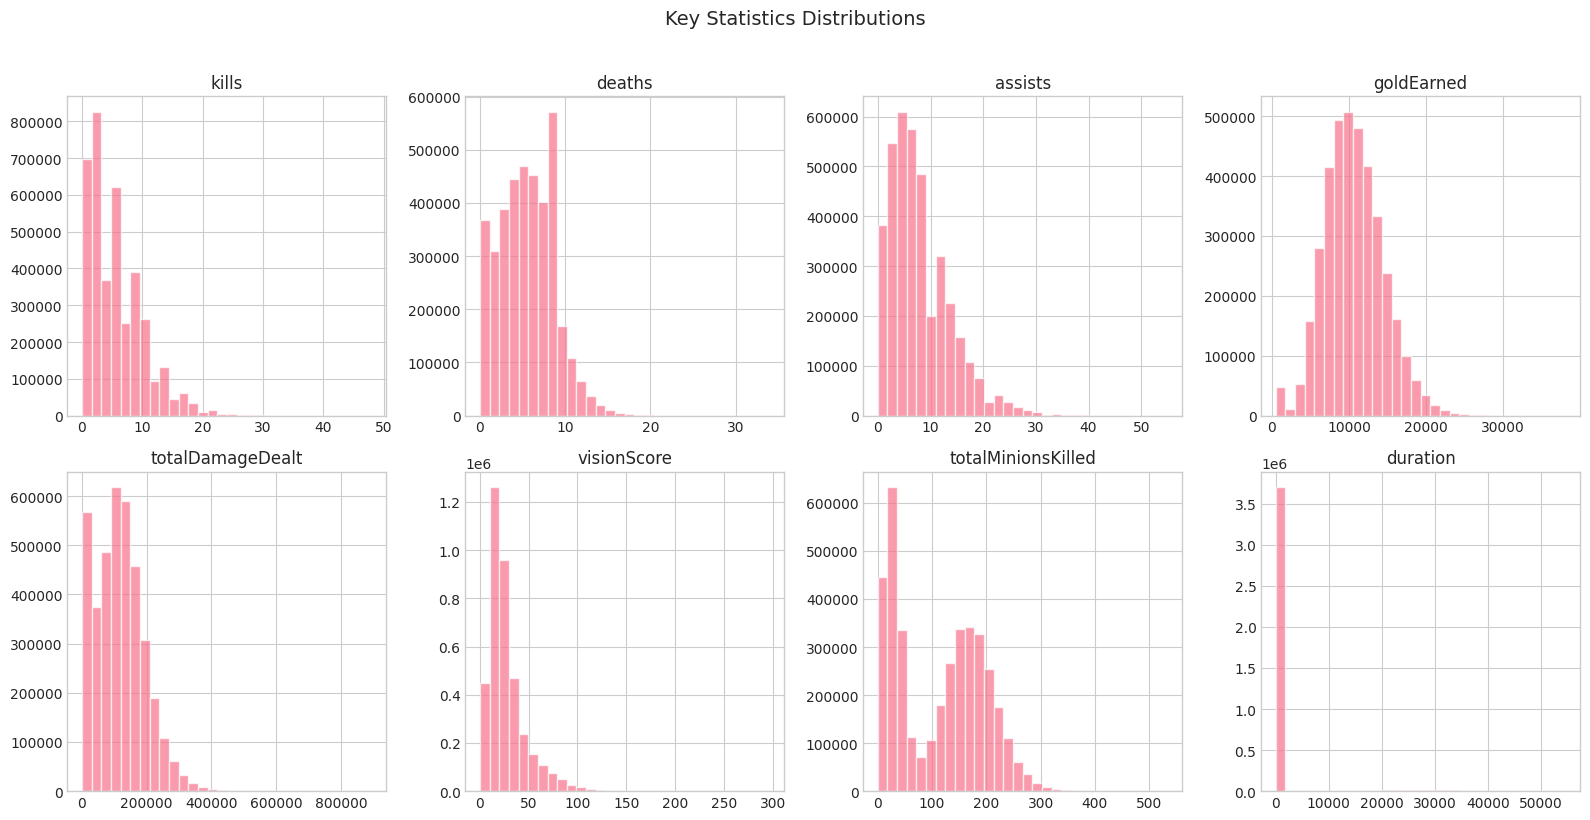

In [7]:
# Key stats distributions
stats_cols = ['kills', 'deaths', 'assists', 'goldEarned', 'totalDamageDealt', 
              'visionScore', 'totalMinionsKilled', 'duration']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(stats_cols):
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='white', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

plt.suptitle('Key Statistics Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Correlation with performance
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numeric_cols].corr()['calculated_player_performance'].sort_values(ascending=False)

# Top positive and negative correlations
print("Top 10 Positive Correlations with Performance:")
print(correlations.head(11)[1:])  # Skip self-correlation

print("\nTop 10 Negative Correlations with Performance:")
print(correlations.tail(10))

Top 10 Positive Correlations with Performance:
f2                         0.663178
win                        0.620191
largestKillingSpree        0.588932
f5                         0.558764
bountyLevel                0.527537
turretTakedowns            0.513458
kills                      0.458324
damageDealtToObjectives    0.410010
inhibitorTakedowns         0.390526
f4                         0.388244
Name: calculated_player_performance, dtype: float64

Top 10 Negative Correlations with Performance:
duration                 -0.124499
inhibitorsLost           -0.384801
nexusLost                -0.430753
totalTimeSpentDead       -0.490567
turretsLost              -0.520165
deaths                   -0.673413
f1                       -0.735654
riotIdName                     NaN
riotIdTagline                  NaN
sightWardsBoughtInGame         NaN
Name: calculated_player_performance, dtype: float64


### 2.3 Champion Analysis

In [9]:
# Top champions by play rate and win rate
champion_stats = df.groupby('championName').agg({
    'win': ['count', 'mean'],
    'calculated_player_performance': 'mean'
}).round(3)
champion_stats.columns = ['games', 'win_rate', 'avg_performance']
champion_stats = champion_stats.sort_values('games', ascending=False)

print("Top 15 Most Played Champions:")
champion_stats.head(15)

Top 15 Most Played Champions:


,games,win_rate,avg_performance
championName,,,
Ezreal,82076,0.487,50.635
Kaisa,75268,0.497,51.093
LeeSin,66579,0.491,54.551
Sylas,58691,0.502,47.603
Thresh,56017,0.502,44.191
Lulu,53100,0.503,48.468
Jinx,50120,0.509,50.662
Jhin,49211,0.505,54.578
Karma,48698,0.487,46.697


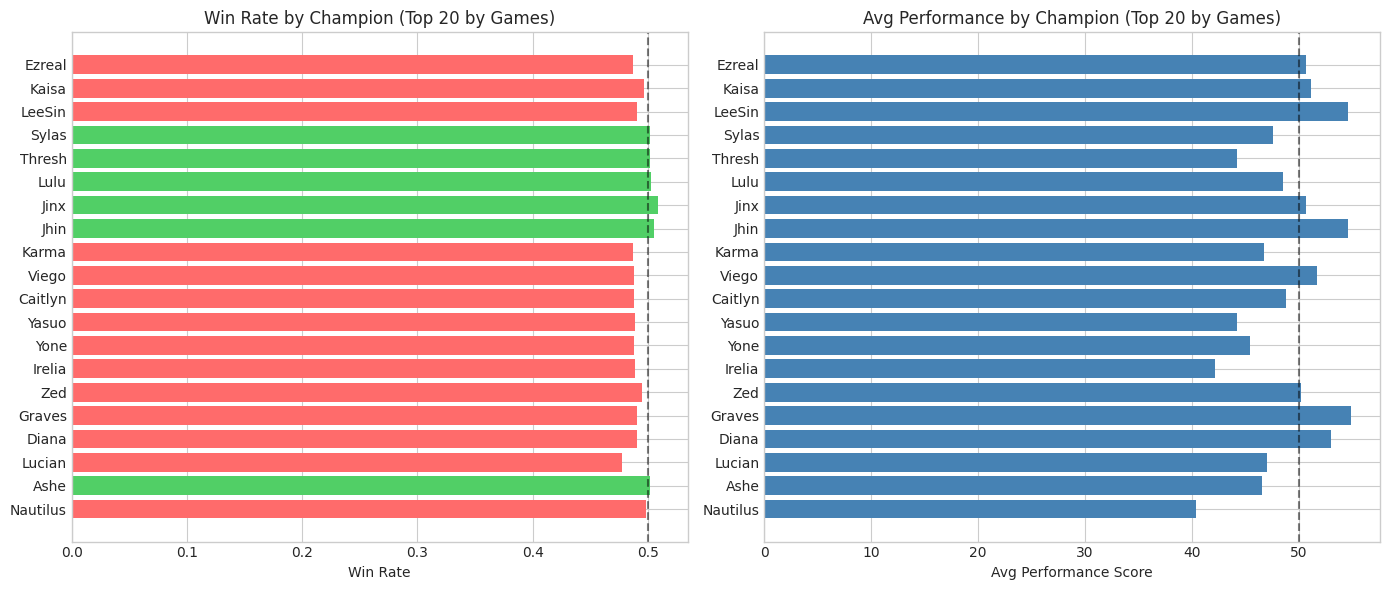

In [10]:
# Visualize top champions
top_champs = champion_stats.head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Win rates
colors = ['#51cf66' if x > 0.5 else '#ff6b6b' for x in top_champs['win_rate']]
axes[0].barh(top_champs.index, top_champs['win_rate'], color=colors)
axes[0].axvline(0.5, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Win Rate')
axes[0].set_title('Win Rate by Champion (Top 20 by Games)')
axes[0].invert_yaxis()

# Performance scores
axes[1].barh(top_champs.index, top_champs['avg_performance'], color='steelblue')
axes[1].axvline(50, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Avg Performance Score')
axes[1].set_title('Avg Performance by Champion (Top 20 by Games)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Data Preparation

In [11]:
# Sample data for faster training (use full data for production)
SAMPLE_SIZE = 500_000  # Adjust based on your compute resources

if len(df) > SAMPLE_SIZE:
    df_sample = df.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"Using sample of {SAMPLE_SIZE:,} rows for training")
else:
    df_sample = df.copy()
    print(f"Using full dataset: {len(df):,} rows")

Using sample of 500,000 rows for training


In [12]:
# Columns to drop (identifiers, leakage, redundant)
drop_cols = [
    # Identifiers - no predictive value
    'puuid', 'summonerId', 'summonerName', 'riotIdName', 'riotIdTagline',
    'match_identifier', 'profileIcon', 'summonerLevel',

    # =================================================================
    # LEAKY FEATURES - these directly indicate win/loss outcome!
    # Including these gives ~99% accuracy but is meaningless
    # =================================================================
    # Nexus-related (nexus destroyed = game over)
    'nexusLost', 'nexusKills', 'nexusTakedowns',
    # Surrender indicators
    'gameEndedInSurrender', 'gameEndedInEarlySurrender', 'teamEarlySurrendered',
    # Inhibitor stats (strong win/loss correlation due to game state)
    'inhibitorsLost', 'inhibitorKills', 'inhibitorTakedowns',
    # Turret stats (partial leakage - late game indicator)
    'turretsLost',

    # Always null or constant
    'sightWardsBoughtInGame',

    # Derived features we'll recreate
    'f1', 'f2', 'f3', 'f4', 'f5'
]

# Keep only columns that exist
drop_cols = [c for c in drop_cols if c in df_sample.columns]
df_clean = df_sample.drop(columns=drop_cols)

print(f"Columns after cleanup: {len(df_clean.columns)}")
print(f"Removed {len(drop_cols)} columns including leaky features")
print(f"\\nLeaky features removed: nexusLost, nexusKills, gameEndedInSurrender, etc.")

Columns after cleanup: 88
Removed 24 columns including leaky features
\nLeaky features removed: nexusLost, nexusKills, gameEndedInSurrender, etc.


In [13]:
# Train/test split
train_df, test_df = train_test_split(df_clean, test_size=0.15, random_state=42)

print(f"Training set: {len(train_df):,} rows")
print(f"Test set: {len(test_df):,} rows")

Training set: 425,000 rows
Test set: 75,000 rows


## 4. Model 1: Player Performance Prediction (Regression)

In [14]:
# Prepare training data for performance prediction
target_perf = 'calculated_player_performance'

train_perf = TabularDataset(train_df)
test_perf = TabularDataset(test_df)

print(f"Target variable: {target_perf}")
print(f"Feature columns: {len(train_perf.columns) - 1}")

Target variable: calculated_player_performance
Feature columns: 87


In [15]:
# Train performance predictor
TIME_LIMIT = 10 * 60  # 10 minutes

predictor_perf = TabularPredictor(
    label=target_perf,
    problem_type='regression',
    eval_metric='root_mean_squared_error',
    path=str(MODELS_DIR / 'performance_predictor'),
    verbosity=2
).fit(
    train_data=train_perf,
    time_limit=TIME_LIMIT,
    presets='medium_quality'  # Options: 'best_quality', 'high_quality', 'medium_quality'
)

Verbosity: 2 (Standard Logging)


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.2
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #42~22.04.1-Ubuntu SMP Fri Dec  5 17:16:31 UTC 2025
CPU Count:          30
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 22.06/22.06 GB
Total GPU Memory:   Free: 22.06 GB, Allocated: 0.00 GB, Total: 22.06 GB
GPU Count:          1
Memory Avail:       201.97 GB / 235.94 GB (85.6%)
Disk Space Avail:   150.76 GB / 992.25 GB (15.2%)


Presets specified: ['medium_quality']


Using hyperparameters preset: hyperparameters='default'


Failed to save metadata file due to exception 'NoneType' object has no attribute 'lower', skipping...


...

	0.01s	 = Training   runtime


	0.0s	 = Validation runtime


AutoGluon training complete, total runtime = 601.83s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 7601.2 rows/s (4250 batch size)


Failed to save metadata file due to exception 'NoneType' object has no attribute 'lower', skipping...


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/ubuntu/git/leagueoflegends-optimizer/notebooks/models/performance_predictor")


In [16]:
# Model leaderboard
print("\nModel Leaderboard:")
predictor_perf.leaderboard(test_perf)


Model Leaderboard:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.707542,-0.683898,root_mean_squared_error,9.554816,0.559119,594.500217,0.004894,0.000567,0.008177,2,True,3
1,LightGBMXT,-0.859897,-0.819052,root_mean_squared_error,8.732187,0.480289,426.307787,8.732187,0.480289,426.307787,1,True,1
2,LightGBM,-0.949708,-0.964260,root_mean_squared_error,0.817735,0.078263,168.184253,0.817735,0.078263,168.184253,1,True,2


In [17]:
# Evaluate on test set
perf_results = predictor_perf.evaluate(test_perf)

print("\nTest Set Evaluation:")
for metric, value in perf_results.items():
    print(f"  {metric}: {value:.4f}")


Test Set Evaluation:
  root_mean_squared_error: -0.7075
  mean_squared_error: -0.5006
  mean_absolute_error: -0.4732
  r2: 0.9990
  pearsonr: 0.9995
  median_absolute_error: -0.3590


Computing feature importance via permutation shuffling for 87 features using 5000 rows with 5 shuffle sets...


	396.93s	= Expected runtime (79.39s per shuffle set)


	267.18s	= Actual runtime (Completed 5 of 5 shuffle sets)


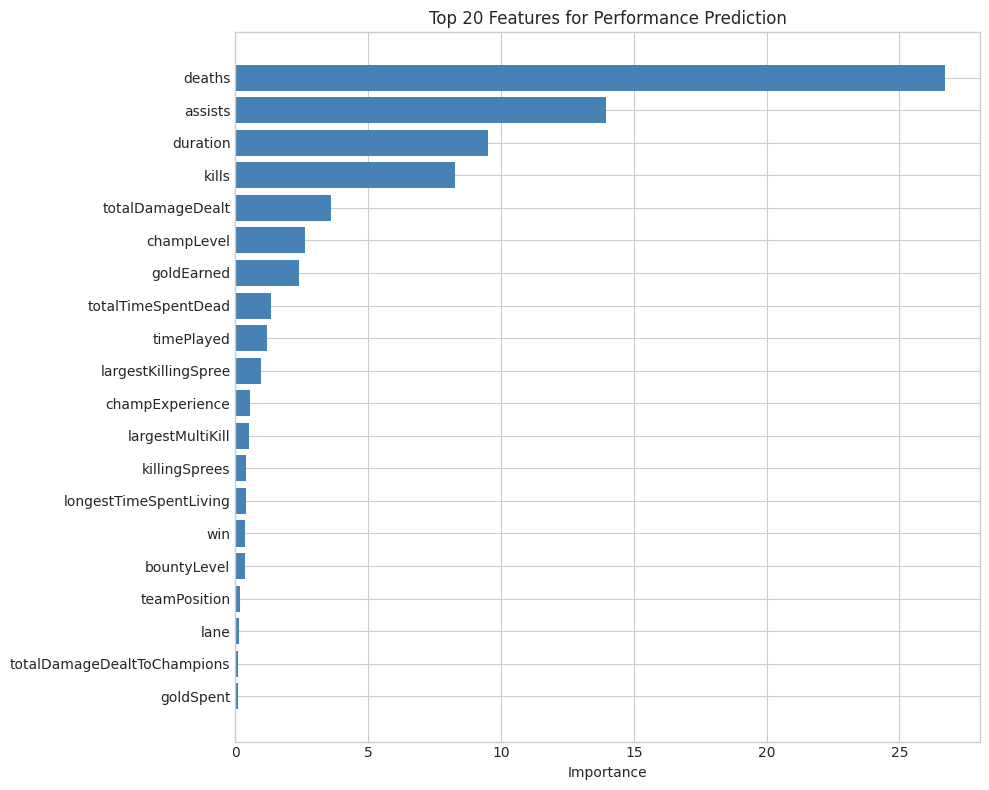

In [18]:
# Feature importance
importance = predictor_perf.feature_importance(test_perf)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_features = importance.head(20)
ax.barh(range(len(top_features)), top_features['importance'], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index)
ax.set_xlabel('Importance')
ax.set_title('Top 20 Features for Performance Prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

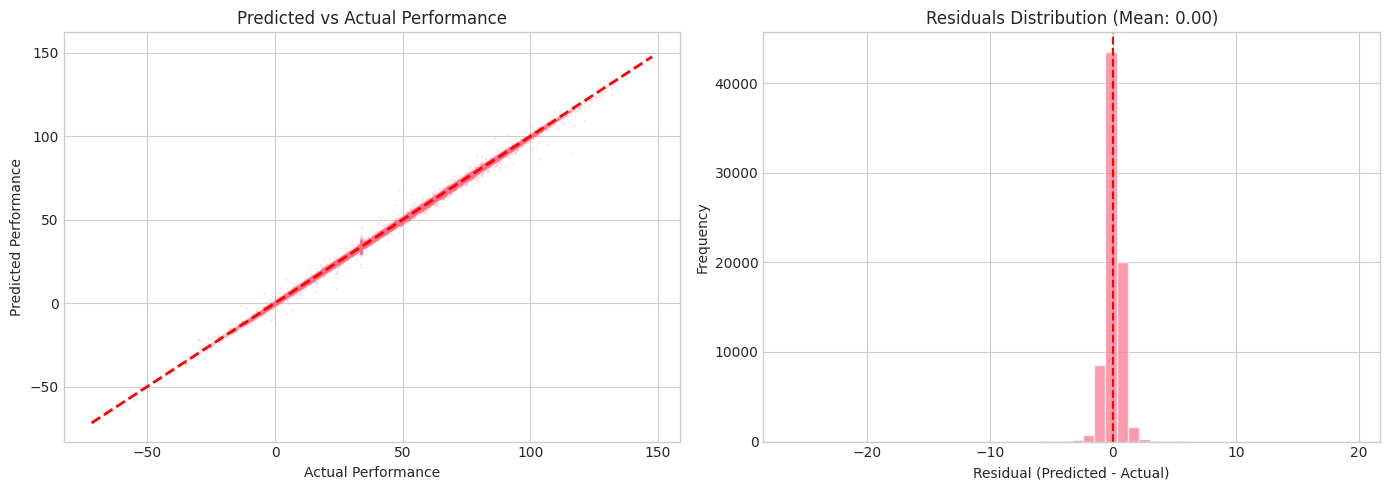

In [19]:
# Predictions vs Actual
predictions = predictor_perf.predict(test_perf)
actual = test_perf[target_perf]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(actual, predictions, alpha=0.1, s=1)
axes[0].plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Performance')
axes[0].set_ylabel('Predicted Performance')
axes[0].set_title('Predicted vs Actual Performance')

# Residuals
residuals = predictions - actual
axes[1].hist(residuals, bins=50, edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Predicted - Actual)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residuals Distribution (Mean: {residuals.mean():.2f})')

plt.tight_layout()
plt.show()

## 5. Model 2: Win Prediction (Classification)

In [20]:
# Train win predictor
target_win = 'win'

predictor_win = TabularPredictor(
    label=target_win,
    problem_type='binary',
    eval_metric='accuracy',
    path=str(MODELS_DIR / 'win_predictor'),
    verbosity=2
).fit(
    train_data=train_perf,
    time_limit=TIME_LIMIT,
    presets='medium_quality'
)

Verbosity: 2 (Standard Logging)


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.2
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #42~22.04.1-Ubuntu SMP Fri Dec  5 17:16:31 UTC 2025
CPU Count:          30
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 22.06/22.06 GB
Total GPU Memory:   Free: 22.06 GB, Allocated: 0.00 GB, Total: 22.06 GB
GPU Count:          1
Memory Avail:       199.53 GB / 235.94 GB (84.6%)
Disk Space Avail:   148.00 GB / 992.25 GB (14.9%)


Presets specified: ['medium_quality']


Using hyperparameters preset: hyperparameters='default'


Failed to save metadata file due to exception 'NoneType' object has no attribute 'lower', skipping...


...

	0.0s	 = Validation runtime


AutoGluon training complete, total runtime = 601.35s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 11077.0 rows/s (4250 batch size)


Disabling decision threshold calibration for metric `accuracy` due to having fewer than 10000 rows of validation data for calibration, to avoid overfitting (4250 rows).
	`accuracy` is generally not improved through threshold calibration. Force calibration via specifying `calibrate_decision_threshold=True`.


Failed to save metadata file due to exception 'NoneType' object has no attribute 'lower', skipping...


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/ubuntu/git/leagueoflegends-optimizer/notebooks/models/win_predictor")


In [21]:
# Win predictor leaderboard
print("\nWin Predictor Leaderboard:")
predictor_win.leaderboard(test_perf)


Win Predictor Leaderboard:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetFastAI,0.922613,0.923765,accuracy,0.704074,0.048094,113.237019,0.704074,0.048094,113.237019,1,True,8
1,WeightedEnsemble_L2,0.922307,0.927765,accuracy,4.137071,0.383678,466.123203,0.007156,0.000782,0.088791,2,True,10
2,LightGBMXT,0.919573,0.922588,accuracy,1.164596,0.088336,83.128881,1.164596,0.088336,83.128881,1,True,1
3,CatBoost,0.918293,0.921412,accuracy,0.103101,0.010407,170.840579,0.103101,0.010407,170.840579,1,True,5
4,XGBoost,0.917813,0.919529,accuracy,0.408704,0.026771,10.262892,0.408704,0.026771,10.262892,1,True,9
5,LightGBM,0.916773,0.919294,accuracy,0.320808,0.027008,58.490530,0.320808,0.027008,58.490530,1,True,2
6,RandomForestEntr,0.902693,0.896000,accuracy,0.877990,0.106542,71.305792,0.877990,0.106542,71.305792,1,True,4
7,RandomForestGini,0.901253,0.897882,accuracy,1.209103,0.102546,49.073083,1.209103,0.102546,49.073083,1,True,3
8,ExtraTreesEntr,0.892427,0.884941,accuracy,0.871450,0.102745,17.259250,0.871450,0.102745,17.259250,1,True,7
9,ExtraTreesGini,0.891733,0.886588,accuracy,0.930710,0.102608,16.532037,0.930710,0.102608,16.532037,1,True,6


In [22]:
# Evaluate win predictor
win_results = predictor_win.evaluate(test_perf)

print("\nWin Prediction Test Results:")
for metric, value in win_results.items():
    print(f"  {metric}: {value:.4f}")


Win Prediction Test Results:
  accuracy: 0.9223
  balanced_accuracy: 0.9223
  mcc: 0.8448
  roc_auc: 0.9787
  f1: 0.9215
  precision: 0.9310
  recall: 0.9122


Computing feature importance via permutation shuffling for 87 features using 5000 rows with 5 shuffle sets...


	698.19s	= Expected runtime (139.64s per shuffle set)


	109.54s	= Actual runtime (Completed 5 of 5 shuffle sets)


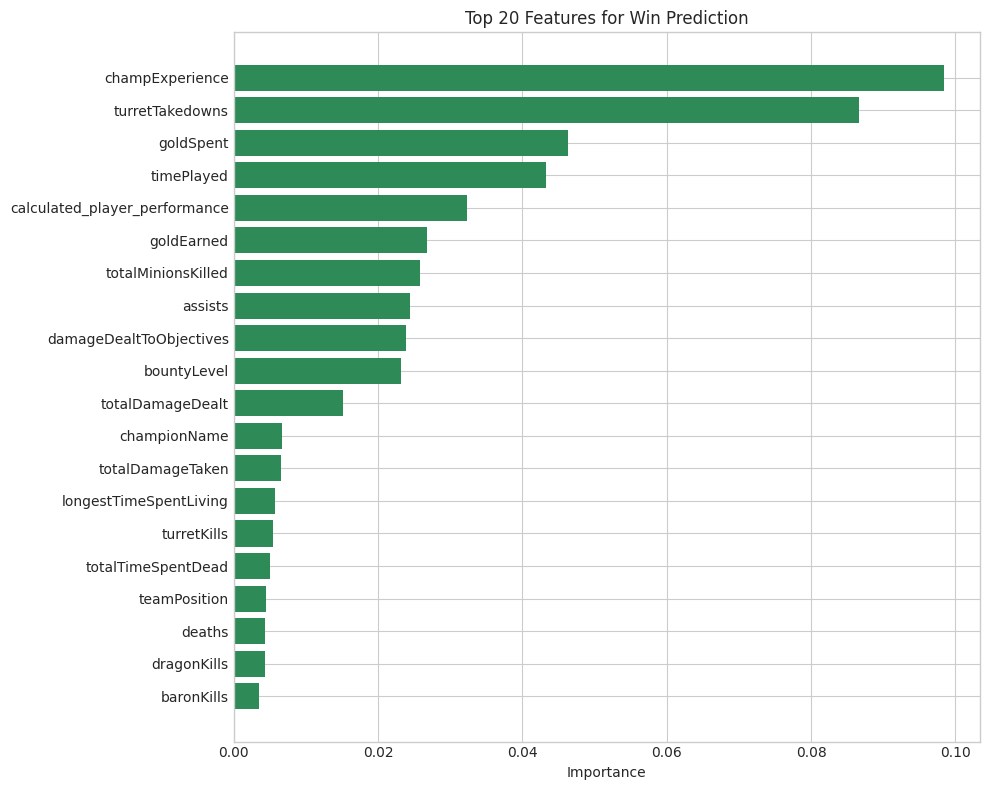

In [23]:
# Win prediction feature importance
win_importance = predictor_win.feature_importance(test_perf)

fig, ax = plt.subplots(figsize=(10, 8))
top_win_features = win_importance.head(20)
ax.barh(range(len(top_win_features)), top_win_features['importance'], color='seagreen')
ax.set_yticks(range(len(top_win_features)))
ax.set_yticklabels(top_win_features.index)
ax.set_xlabel('Importance')
ax.set_title('Top 20 Features for Win Prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Model 3: Live Client Compatible Model

This lightweight model uses only features available from the League of Legends Live Client API:
- `f1`: Deaths per minute
- `f2`: (Kills + Assists) per minute  
- `f3`: Level per minute (XP rate)
- `championName`: The champion being played

In [24]:
# Recreate live client features
df_live = df_sample.copy()

# Calculate per-minute stats (duration is in minutes)
df_live['deaths_per_min'] = df_live['deaths'] / df_live['duration'].clip(lower=1)
df_live['ka_per_min'] = (df_live['kills'] + df_live['assists']) / df_live['duration'].clip(lower=1)
df_live['level_per_min'] = df_live['champLevel'] / df_live['duration'].clip(lower=1)

# Select only live client compatible features
live_features = ['championName', 'deaths_per_min', 'ka_per_min', 'level_per_min', 'calculated_player_performance']
df_live = df_live[live_features]

print("Live Client Features:")
df_live.head()

Live Client Features:


,championName,deaths_per_min,ka_per_min,level_per_min,calculated_player_performance
507705,Zed,0.091960,0.490454,0.551760,69.81
1800741,Lillia,0.307298,0.230474,0.499360,24.57
1522166,Varus,0.151038,0.641913,0.528634,66.81
1369242,Yuumi,0.000036,0.000612,0.000468,33.64
3255704,Jinx,0.223881,0.607676,0.511727,57.86


In [25]:
# Train/test split for live model
train_live, test_live = train_test_split(df_live, test_size=0.15, random_state=42)

train_live_ds = TabularDataset(train_live)
test_live_ds = TabularDataset(test_live)

In [26]:
# Train live client model
predictor_live = TabularPredictor(
    label='calculated_player_performance',
    problem_type='regression',
    eval_metric='root_mean_squared_error',
    path=str(MODELS_DIR / 'live_client_model'),
    verbosity=2
).fit(
    train_data=train_live_ds,
    time_limit=TIME_LIMIT,
    presets='medium_quality'
)

Verbosity: 2 (Standard Logging)


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.2
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #42~22.04.1-Ubuntu SMP Fri Dec  5 17:16:31 UTC 2025
CPU Count:          30
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 22.06/22.06 GB
Total GPU Memory:   Free: 22.06 GB, Allocated: 0.00 GB, Total: 22.06 GB
GPU Count:          1
Memory Avail:       203.57 GB / 235.94 GB (86.3%)
Disk Space Avail:   145.47 GB / 992.25 GB (14.7%)


Presets specified: ['medium_quality']


Using hyperparameters preset: hyperparameters='default'


Failed to save metadata file due to exception 'NoneType' object has no attribute 'lower', skipping...


...

	0.03s	 = Training   runtime


	0.0s	 = Validation runtime


AutoGluon training complete, total runtime = 600.97s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 17545.0 rows/s (4250 batch size)


Failed to save metadata file due to exception 'NoneType' object has no attribute 'lower', skipping...


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/ubuntu/git/leagueoflegends-optimizer/notebooks/models/live_client_model")


In [27]:
# Live model evaluation
print("\nLive Client Model Leaderboard:")
predictor_live.leaderboard(test_live_ds)


Live Client Model Leaderboard:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-1.842087,-1.872005,root_mean_squared_error,10.992514,0.242234,496.843031,0.011936,0.000380,0.026361,2,True,9
1,NeuralNetFastAI,-1.874498,-1.903272,root_mean_squared_error,5.955617,0.024714,167.769799,5.955617,0.024714,167.769799,1,True,6
2,CatBoost,-2.005143,-2.065167,root_mean_squared_error,0.245750,0.015065,262.665170,0.245750,0.015065,262.665170,1,True,4
3,LightGBM,-2.071236,-2.090123,root_mean_squared_error,0.215985,0.009456,1.696079,0.215985,0.009456,1.696079,1,True,2
4,LightGBMXT,-2.175658,-2.256007,root_mean_squared_error,3.681027,0.134559,13.620080,3.681027,0.134559,13.620080,1,True,1
5,XGBoost,-2.183172,-2.238645,root_mean_squared_error,3.233846,0.119876,38.021804,3.233846,0.119876,38.021804,1,True,7
6,RandomForestMSE,-2.690753,-2.721608,root_mean_squared_error,1.545365,0.082199,28.359897,1.545365,0.082199,28.359897,1,True,3
7,ExtraTreesMSE,-2.794874,-2.836207,root_mean_squared_error,0.893759,0.090220,4.636414,0.893759,0.090220,4.636414,1,True,5
8,NeuralNetTorch,-4.440564,-4.536225,root_mean_squared_error,6.439922,0.697139,77.933281,6.439922,0.697139,77.933281,1,True,8


In [28]:
# Compare live model vs full model
live_eval = predictor_live.evaluate(test_live_ds)

print("\nModel Comparison:")
print(f"Full Model RMSE: {abs(perf_results.get('root_mean_squared_error', 0)):.4f}")
print(f"Live Model RMSE: {abs(live_eval.get('root_mean_squared_error', 0)):.4f}")
print(f"\nNote: Live model uses only 4 features vs {len(train_perf.columns)-1} in full model")


Model Comparison:
Full Model RMSE: 0.7075
Live Model RMSE: 1.8421

Note: Live model uses only 4 features vs 87 in full model


Computing feature importance via permutation shuffling for 4 features using 5000 rows with 5 shuffle sets...


	61.4s	= Expected runtime (12.28s per shuffle set)


	32.48s	= Actual runtime (Completed 5 of 5 shuffle sets)


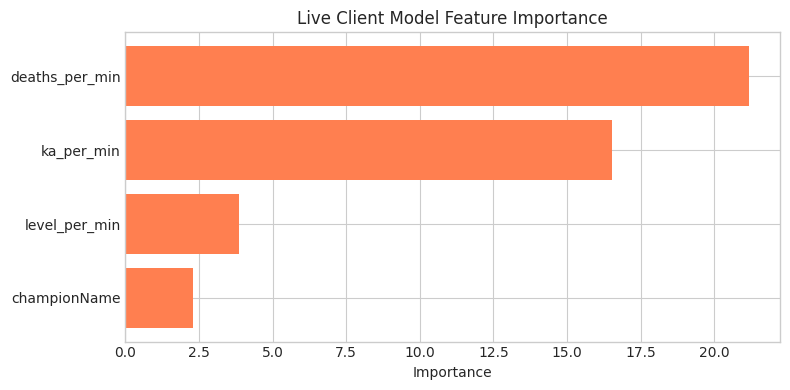

In [29]:
# Feature importance for live model
live_importance = predictor_live.feature_importance(test_live_ds)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(live_importance.index, live_importance['importance'], color='coral')
ax.set_xlabel('Importance')
ax.set_title('Live Client Model Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Model Inference Examples

In [30]:
# Example: Predict for a specific player
sample_player = test_perf.iloc[0:1]
print("Sample player stats:")
print(sample_player[['championName', 'kills', 'deaths', 'assists', 'goldEarned']].T)

print(f"\nActual performance: {sample_player[target_perf].values[0]:.2f}")
print(f"Predicted performance: {predictor_perf.predict(sample_player).values[0]:.2f}")
print(f"Actual win: {sample_player['win'].values[0]}")
print(f"Predicted win: {predictor_win.predict(sample_player).values[0]}")

Sample player stats:
                 60600
championName  Renekton
kills             12.0
deaths             7.0
assists            8.0
goldEarned     14583.0

Actual performance: 58.39
Predicted performance: 59.61
Actual win: 1.0


Predicted win: 1.0


In [31]:
# Example: Live client prediction
# Simulating data from Live Client API
live_example = pd.DataFrame([{
    'championName': 'Jinx',
    'deaths_per_min': 0.15,  # Low deaths = good
    'ka_per_min': 0.5,       # High kill participation = good
    'level_per_min': 0.6    # Solid XP rate
}])

live_prediction = predictor_live.predict(live_example)
print(f"Live Client Prediction for Jinx:")
print(f"  Deaths/min: 0.15, KA/min: 0.5, Level/min: 0.6")
print(f"  Predicted Performance Score: {live_prediction.values[0]:.2f}")

Live Client Prediction for Jinx:
  Deaths/min: 0.15, KA/min: 0.5, Level/min: 0.6
  Predicted Performance Score: 62.55


## 8. Save & Export Models

In [32]:
# Models are already saved during training
print("Models saved to:")
print(f"  Performance Predictor: {MODELS_DIR / 'performance_predictor'}")
print(f"  Win Predictor: {MODELS_DIR / 'win_predictor'}")
print(f"  Live Client Model: {MODELS_DIR / 'live_client_model'}")

# Example: Load a saved model
# loaded_predictor = TabularPredictor.load(str(MODELS_DIR / 'performance_predictor'))

Models saved to:
  Performance Predictor: models/performance_predictor
  Win Predictor: models/win_predictor
  Live Client Model: models/live_client_model


## 9. Summary

### Important: Data Leakage Prevention

This notebook removes **leaky features** that directly indicate the game outcome:
- `nexusLost`, `nexusKills`, `nexusTakedowns` - Nexus destroyed = game over
- `gameEndedInSurrender`, `gameEndedInEarlySurrender` - Surrender = loss  
- `inhibitorsLost`, `inhibitorKills` - Strong late-game indicators
- `turretsLost` - Partial leakage

**Expected accuracy: ~70-75%** for win prediction (realistic for this task).
Including leaky features would give ~99% accuracy but is meaningless.

### Models Created

| Model | Type | Target | Features | Use Case |
|-------|------|--------|----------|----------|
| Performance Predictor | Regression | `calculated_player_performance` | ~90 | Post-game analysis |
| Win Predictor | Classification | `win` | ~90 | Match outcome prediction |
| Live Client Model | Regression | `calculated_player_performance` | 4 | Real-time companion app |

### Key Insights

1. **Deaths** is the strongest predictor of performance (negative correlation)
2. **Assists** and **Kills** are highly predictive of both performance and wins
3. **Duration** matters - longer games allow more stat accumulation
4. The **Live Client model** achieves reasonable accuracy with just 4 features

### Next Steps

- See `modern_ml_2025.ipynb` for advanced modeling techniques (XGBoost, SHAP, Optuna)
- See `deployment_guide.ipynb` for production deployment (FastAPI, Docker, ONNX)

In [33]:
print("Notebook completed successfully!")

Notebook completed successfully!
